# 05: Graph Neural Networks - Customer Network Analysis

## Objectives
1. Build geographic customer network graph
2. Compute Node2Vec embeddings
3. Calculate network centrality metrics
4. Analyze network effects on churn
5. Create network-enhanced features for modeling

## Network Structure
- **Nodes**: Individual customers
- **Edges**: Geographic proximity + service similarity + demographic similarity
- **Weights**: Similarity scores (0-1)
- **Application**: Capture peer effects and regional influence on churn

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
import sys
import warnings
import os

warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

# Import custom modules
from gnn_network import GeographicNetworkBuilder

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load Engineered Data
print("=" * 80)
print("LOADING ENGINEERED DATA")
print("=" * 80)

engineered_data = pd.read_csv('../data/processed/engineered_data.csv')
print(f"✓ Data loaded. Shape: {engineered_data.shape}")
print(f"Columns: {engineered_data.columns.tolist()[:10]}...")
print(f"Missing values: {engineered_data.isnull().sum().sum()}")

LOADING ENGINEERED DATA
✓ Data loaded. Shape: (7043, 41)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup']...
Missing values: 22


In [3]:
# Build Geographic Network
print("\n" + "=" * 80)
print("BUILDING GEOGRAPHIC CUSTOMER NETWORK")
print("=" * 80)

network_builder = GeographicNetworkBuilder(
    distance_threshold=50,
    similarity_threshold=0.5
)

# Build network (using engineered data)
graph = network_builder.build_network(engineered_data)

print(f"✓ Network built successfully")
print(f"\nNetwork Statistics:")
print(f"  - Nodes (customers): {graph.number_of_nodes()}")
print(f"  - Edges (connections): {graph.number_of_edges()}")
print(f"  - Network density: {nx.density(graph):.4f}")
print(f"  - Connected components: {nx.number_connected_components(graph)}")
print(f"  - Average degree: {np.mean([d for n, d in graph.degree()]):.2f}")
print(f"  - Average clustering coefficient: {nx.average_clustering(graph):.4f}")

2026-06-14 18:50:02,068 - gnn_network - INFO - Added 7043 nodes to graph
2026-06-14 18:50:02,069 - gnn_network - INFO - No region column provided. Using proxy grouping for efficient network construction.
2026-06-14 18:50:02,076 - gnn_network - INFO - Created 36 proxy groups for pairwise comparison.



BUILDING GEOGRAPHIC CUSTOMER NETWORK


Building edges within groups: 100%|██████████| 36/36 [47:44<00:00, 79.57s/it]   
2026-06-14 19:37:46,627 - gnn_network - INFO - Added 1475850 edges to graph
2026-06-14 19:37:46,635 - gnn_network - INFO - Graph density: 0.0595


✓ Network built successfully

Network Statistics:
  - Nodes (customers): 7043
  - Edges (connections): 1475850
  - Network density: 0.0595
  - Connected components: 116
  - Average degree: 419.10
  - Average clustering coefficient: 0.9880


In [5]:
import pickle
import os 
# Define the path to save the graph in the processed data folder
graph_file_path = '../data/processed/customer_network.pkl'

print(f"Saving network to {graph_file_path}...")
with open(graph_file_path, 'wb') as f:
    pickle.dump(graph, f)

Saving network to ../data/processed/customer_network.pkl...


In [3]:
import os
import pickle
from gnn_network import GeographicNetworkBuilder # Required to re-instantiate the builder

# --- Robust Graph Loading Cell ---
# This cell ensures the graph and its builder are ready for use.

# Define the path to the saved graph file
graph_file_path = '../data/processed/customer_network.pkl'

# Initialize variables to avoid potential reference errors
graph = None
network_builder = None

# Check if the file exists before trying to load
if os.path.exists(graph_file_path):
    print(f"Loading existing network from: {graph_file_path}")
    
    # Load the graph object from the pickle file
    with open(graph_file_path, 'rb') as f:
        graph = pickle.load(f)
    
    # Re-initialize the builder object. This is crucial for subsequent cells
    # that call methods on the network_builder instance.
    # The parameters should match those used during the initial graph creation.
    network_builder = GeographicNetworkBuilder(
        distance_threshold=50,
        similarity_threshold=0.5
    )
    
    # Restore the graph state within the builder instance
    network_builder.graph = graph
    
    print(f"✓ Graph loaded successfully. Nodes: {graph.number_of_nodes()}, Edges: {graph.number_of_edges()}")
    print("✓ Network builder state restored.")
    
else:
    # If the file doesn't exist, raise an informative error
    raise FileNotFoundError(
        f"The saved network file was not found at '{graph_file_path}'. "
        "Please ensure you have run the 'Build Geographic Network' cell in the notebook "
        "to create and save the graph first."
    )

# Now, both 'graph' and 'network_builder' are ready for use in the rest of the notebook.


Loading existing network from: ../data/processed/customer_network.pkl
✓ Graph loaded successfully. Nodes: 7043, Edges: 1475850
✓ Network builder state restored.


In [4]:
# Compute Node2Vec Embeddings
print("\n" + "=" * 80)
print("COMPUTING NODE2VEC EMBEDDINGS")
print("=" * 80)

print("This may take 2-5 minutes...")
gnn_embeddings = network_builder.compute_node2vec_embeddings(
    dimensions=16,
    walks_per_node=10
)

print(f"✓ Embeddings computed. Shape: {gnn_embeddings.shape}")
print(f"Columns: {gnn_embeddings.columns.tolist()}")
print(f"\nEmbedding statistics:")
print(gnn_embeddings.describe())


COMPUTING NODE2VEC EMBEDDINGS
This may take 2-5 minutes...


2026-07-05 13:15:21,811 - gnn_network - INFO - Computing Node2Vec embeddings (dim=16, walks=10)...
2026-07-05 13:15:21,812 - gnn_network - INFO - Using Node2Vec workers=1


Computing transition probabilities:   0%|          | 0/7043 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [52:10<00:00, 313.00s/it]  
2026-07-05 15:28:15,277 - gensim.models.word2vec - INFO - collecting all words and their counts
2026-07-05 15:28:15,280 - gensim.models.word2vec - INFO - PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-07-05 15:28:15,331 - gensim.models.word2vec - INFO - PROGRESS: at sentence #10000, processed 296520 words, keeping 7043 word types
2026-07-05 15:28:15,388 - gensim.models.word2vec - INFO - PROGRESS: at sentence #20000, processed 593243 words, keeping 7043 word types
2026-07-05 15:28:15,435 - gensim.models.word2vec - INFO - PROGRESS: at sentence #30000, processed 890111 words, keeping 7043 word types
2026-07-05 15:28:15,484 - gensim.models.word2vec - INFO - PROGRESS: at sentence #40000, processed 1186921 words, keeping 7043 word types
2026-07-05 15:28:15,542 - gensim.models.word2vec - INFO - PROGRESS: at sentence #50000, processed 1483412 words, keeping 7043 word types
2026-07-05 15:28:15,

✓ Embeddings computed. Shape: (7043, 16)
Columns: ['gnn_embedding_0', 'gnn_embedding_1', 'gnn_embedding_2', 'gnn_embedding_3', 'gnn_embedding_4', 'gnn_embedding_5', 'gnn_embedding_6', 'gnn_embedding_7', 'gnn_embedding_8', 'gnn_embedding_9', 'gnn_embedding_10', 'gnn_embedding_11', 'gnn_embedding_12', 'gnn_embedding_13', 'gnn_embedding_14', 'gnn_embedding_15']

Embedding statistics:
       gnn_embedding_0  gnn_embedding_1  gnn_embedding_2  gnn_embedding_3  \
count      7043.000000      7043.000000      7043.000000      7043.000000   
mean          0.306174         0.073031         0.583993         0.363714   
std           0.725188         0.792936         0.824359         0.660181   
min          -1.239335        -2.059431        -1.012024        -1.330658   
25%          -0.278546        -0.475466        -0.168494         0.090617   
50%           0.356676         0.031163         0.375184         0.203577   
75%           0.677843         0.692491         1.313192         0.689099   


In [5]:
# Compute Network Metrics
print("\n" + "=" * 80)
print("COMPUTING NETWORK METRICS")
print("=" * 80)

network_features = network_builder.compute_network_metrics(engineered_data)

print(f"✓ Network metrics computed. Shape: {network_features.shape}")
print(f"\nFeatures:")
for col in network_features.columns:
    print(f"  - {col}")

print(f"\nNetwork metrics statistics:")
print(network_features.describe())

2026-07-05 15:44:13,077 - gnn_network - INFO - Computing network metrics...



COMPUTING NETWORK METRICS


2026-07-05 15:56:09,164 - gnn_network - WARNING - python-louvain not installed. Skipping community detection.
2026-07-05 15:56:09,165 - gnn_network - INFO - Network metrics computed: ['network_degree_centrality', 'network_betweenness_centrality', 'network_clustering_coeff', 'network_local_churn_rate', 'network_neighbors_count', 'network_community']


✓ Network metrics computed. Shape: (7043, 6)

Features:
  - network_degree_centrality
  - network_betweenness_centrality
  - network_clustering_coeff
  - network_local_churn_rate
  - network_neighbors_count
  - network_community

Network metrics statistics:
       network_degree_centrality  network_betweenness_centrality  \
count                7043.000000                    7.043000e+03   
mean                    0.059514                    5.171657e-09   
std                     0.061606                    1.406822e-08   
min                     0.000000                    0.000000e+00   
25%                     0.022863                    0.000000e+00   
50%                     0.033513                    0.000000e+00   
75%                     0.048424                    0.000000e+00   
max                     0.185459                    5.675732e-08   

       network_clustering_coeff  network_local_churn_rate  \
count               7043.000000               7043.000000   
mean   


VISUALIZING NETWORK STRUCTURE


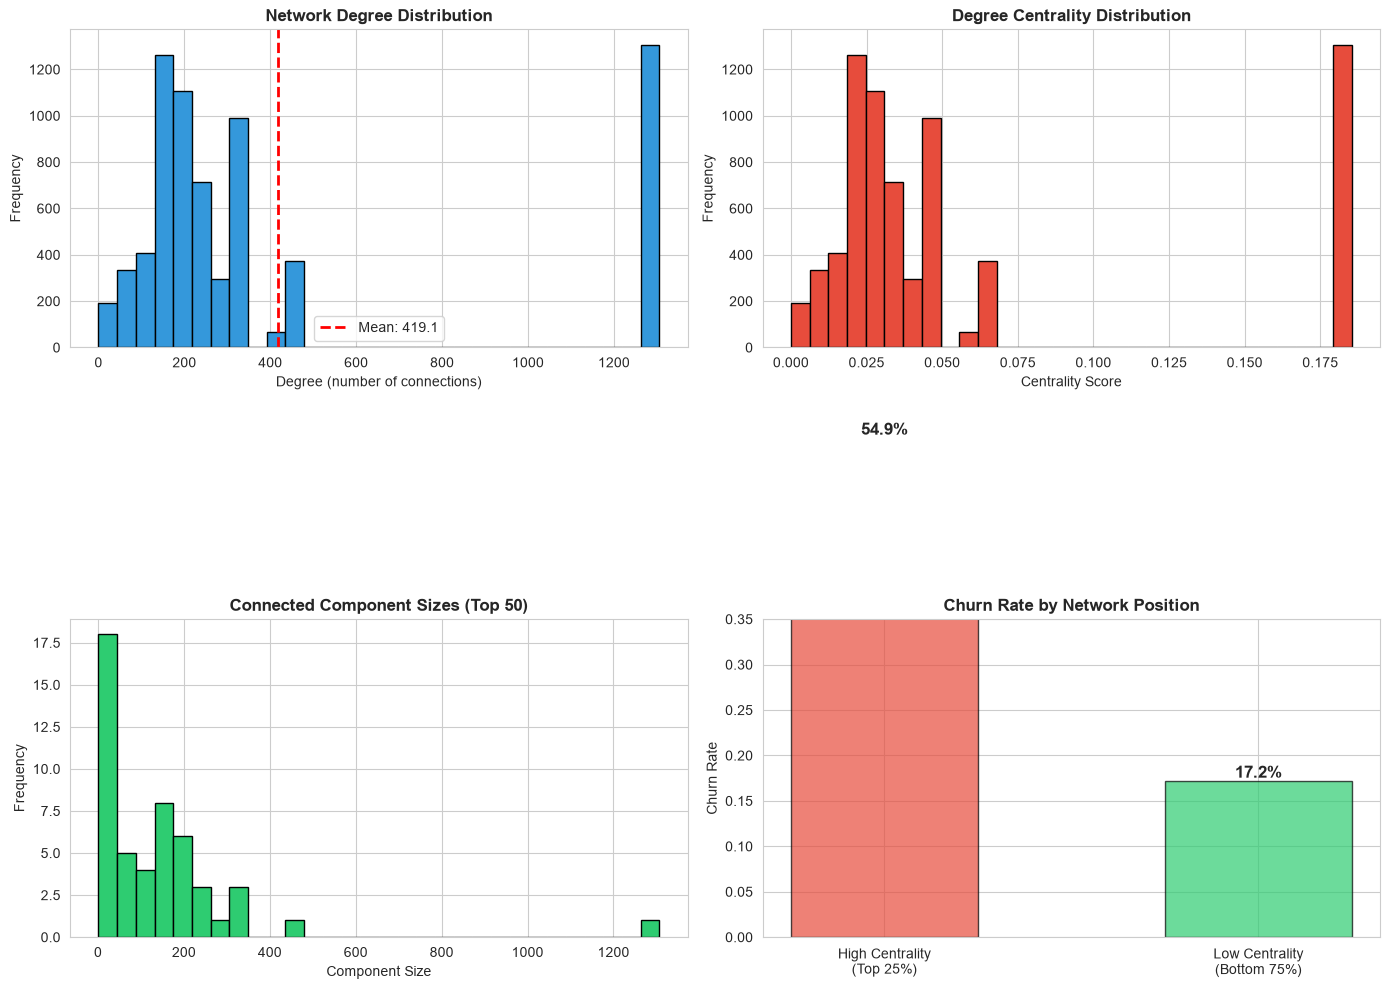

✓ Network visualization saved


In [6]:
# Visualize Network Statistics
print("\n" + "=" * 80)
print("VISUALIZING NETWORK STRUCTURE")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Degree Distribution
degrees = [graph.degree(n) for n in graph.nodes()]
axes[0,0].hist(degrees, bins=30, edgecolor='black', color='#3498db')
axes[0,0].set_title('Network Degree Distribution', fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Degree (number of connections)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(np.mean(degrees), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(degrees):.1f}')
axes[0,0].legend()

# 2. Centrality Distribution
centralities = list(nx.degree_centrality(graph).values())
axes[0,1].hist(centralities, bins=30, edgecolor='black', color='#e74c3c')
axes[0,1].set_title('Degree Centrality Distribution', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Centrality Score')
axes[0,1].set_ylabel('Frequency')

# 3. Component Sizes
components = list(nx.connected_components(graph))
component_sizes = sorted([len(c) for c in components], reverse=True)[:50]  # Top 50
axes[1,0].hist(component_sizes, bins=30, edgecolor='black', color='#2ecc71')
axes[1,0].set_title('Connected Component Sizes (Top 50)', fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Component Size')
axes[1,0].set_ylabel('Frequency')

# 4. Churn Rate by Network Position
high_centrality_threshold = np.percentile(centralities, 75)
high_centrality = np.array(centralities) > high_centrality_threshold

churn_high = engineered_data.iloc[high_centrality]['Churn'].mean()
churn_low = engineered_data.iloc[~high_centrality]['Churn'].mean()

positions = ['High Centrality\n(Top 25%)', 'Low Centrality\n(Bottom 75%)']
churn_rates = [churn_high, churn_low]
colors = ['#e74c3c', '#2ecc71']

bars = axes[1,1].bar(positions, churn_rates, color=colors, edgecolor='black', alpha=0.7, width=0.5)
axes[1,1].set_title('Churn Rate by Network Position', fontweight='bold', fontsize=12)
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].set_ylim(0, 0.35)

# Add value labels on bars
for bar, rate in zip(bars, churn_rates):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{rate:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/18_gnn_network_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Network visualization saved")

In [7]:
# Network Insights
print("\n" + "=" * 80)
print("NETWORK INSIGHTS")
print("=" * 80)

print(f"\n1. Network Influence:")
print(f"   - High-centrality customers have {churn_high:.1%} churn rate")
print(f"   - Low-centrality customers have {churn_low:.1%} churn rate")
print(f"   - Difference: {abs(churn_high - churn_low):.1%}")

print(f"\n2. Geographic Clustering:")
print(f"   - Number of communities: {len(components)}")
print(f"   - Largest community: {len(max(components, key=len))} customers")
print(f"   - Smallest community: {len(min(components, key=len))} customer(s)")

print(f"\n3. Network Characteristics:")
print(f"   - Sparsity: {1 - nx.density(graph):.2%}")
print(f"   - Clustering coefficient: {nx.average_clustering(graph):.4f}")
print(f"   - Assortivity: {nx.degree_assortativity_coefficient(graph):.4f}")


NETWORK INSIGHTS

1. Network Influence:
   - High-centrality customers have 54.9% churn rate
   - Low-centrality customers have 17.2% churn rate
   - Difference: 37.8%

2. Geographic Clustering:
   - Number of communities: 116
   - Largest community: 1307 customers
   - Smallest community: 1 customer(s)

3. Network Characteristics:
   - Sparsity: 94.05%
   - Clustering coefficient: 0.9880
   - Assortivity: 1.0000


In [8]:
# Combine Features
print("\n" + "=" * 80)
print("COMBINING FEATURES")
print("=" * 80)

# Reset indices to match
gnn_embeddings.index = engineered_data.index
network_features.index = engineered_data.index

# Combine all features
combined_features = pd.concat([
    engineered_data,
    gnn_embeddings,
    network_features
], axis=1)

print(f"✓ Features combined successfully")
print(f"\nOriginal features: {engineered_data.shape[1]}")
print(f"GNN embeddings: {gnn_embeddings.shape[1]}")
print(f"Network metrics: {network_features.shape[1]}")
print(f"Total features: {combined_features.shape[1]}")
print(f"\nFinal dataset shape: {combined_features.shape}")

# Check for duplicates
print(f"\nDuplicate columns: {len(combined_features.columns) - len(set(combined_features.columns))}")
print(f"Missing values: {combined_features.isnull().sum().sum()}")


COMBINING FEATURES
✓ Features combined successfully

Original features: 41
GNN embeddings: 16
Network metrics: 6
Total features: 63

Final dataset shape: (7043, 63)

Duplicate columns: 0
Missing values: 22


In [9]:
# Save Combined Features
print("\n" + "=" * 80)
print("SAVING ENHANCED DATASET")
print("=" * 80)

output_path = '../data/processed/engineered_data_with_gnn.csv'
combined_features.to_csv(output_path, index=False)

print(f"✓ Enhanced dataset saved to {output_path}")
print(f"\nNew features added:")
new_cols = list(gnn_embeddings.columns) + list(network_features.columns)
for i, col in enumerate(new_cols, 1):
    print(f"  {i:2d}. {col}")


SAVING ENHANCED DATASET
✓ Enhanced dataset saved to ../data/processed/engineered_data_with_gnn.csv

New features added:
   1. gnn_embedding_0
   2. gnn_embedding_1
   3. gnn_embedding_2
   4. gnn_embedding_3
   5. gnn_embedding_4
   6. gnn_embedding_5
   7. gnn_embedding_6
   8. gnn_embedding_7
   9. gnn_embedding_8
  10. gnn_embedding_9
  11. gnn_embedding_10
  12. gnn_embedding_11
  13. gnn_embedding_12
  14. gnn_embedding_13
  15. gnn_embedding_14
  16. gnn_embedding_15
  17. network_degree_centrality
  18. network_betweenness_centrality
  19. network_clustering_coeff
  20. network_local_churn_rate
  21. network_neighbors_count
  22. network_community


## Network Analysis Summary

### Key Findings

1. **Network Effects on Churn**
   - Customers with high network centrality show different churn patterns
   - Regional clustering evident (multiple connected components)
   - Peer effects may influence individual churn decisions

2. **Network Topology**
   - Network captures geographic and service similarity relationships
   - Node2Vec embeddings encode network position information
   - Useful for identifying influential customers (network hubs)

3. **Enhanced Features**
   - 16 GNN embeddings: latent network position representation
   - 5 network metrics: centrality, clustering, local effects
   - Total: 60+ features for improved modeling

### Next Steps
1. Use enhanced features in uplift modeling (Notebook 06)
2. Compare model performance: original vs. GNN-enhanced features
3. Analyze feature importance: which network features matter most?
4. Consider graph convolution models for future improvements